# 06. Quantum Explainability Experiment

Compare classical SHAP values with gradient-times-input attribution from the trained VQC on five
held-out days. This is an exploratory comparison between different models and attribution scales,
not a validated quantum explainability method. SHAP uses the training period as its background.
The VQC weights come from notebook 04 so the explanation refers to the reported classifier.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pennylane import numpy as pnp
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from src.classical_model import train_baseline_model, compute_shap_values
from src.features import FEATURE_COLUMNS
from src.quantum_model import make_circuit, train_vqc, quantum_gradient_attribution, RANDOM_STATE

## Rebuild the same train/test split and features

In [2]:
features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
selected_features = FEATURE_COLUMNS

X = features[selected_features]
y = features['stress']

split_idx = int(len(features) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

## Retrain classical model, compute SHAP on the test set

In [3]:
classical_model = train_baseline_model(X_train, y_train)
shap_values = compute_shap_values(classical_model, X_train, X_test)
print("SHAP values computed with the training period as background.")

Background dataset has 1401 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1401 when initializing the masker.


SHAP values computed with the training period as background.


## Rebuild preprocessing and load the VQC trained in notebook 04

In [4]:
std_scaler = StandardScaler().fit(X_train)
X_train_std = std_scaler.transform(X_train)
X_test_std = std_scaler.transform(X_test)

angle_scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(X_train_std)
X_train_angle = angle_scaler.transform(X_train_std)
X_test_angle = angle_scaler.transform(X_test_std)

N_QUBITS = 4
circuit = make_circuit(n_qubits=N_QUBITS)
weights = pnp.array(
    np.load('../data/processed/vqc_weights.npy'),
    requires_grad=False,
)
print("Loaded VQC weights from notebook 04.")

Loaded VQC weights from notebook 04.


## Pick a handful of test samples

3 stress days and 2 normal days, for a mix of both classes.

In [5]:
sample_rng = np.random.default_rng(RANDOM_STATE)
test_stress_pos = np.where(y_test.values == 1)[0]
test_normal_pos = np.where(y_test.values == 0)[0]

sample_positions = np.concatenate([
    sample_rng.choice(test_stress_pos, size=3, replace=False),
    sample_rng.choice(test_normal_pos, size=2, replace=False),
])

sample_dates = X_test.index[sample_positions]
print("Sample dates and true labels:")
for pos, date in zip(sample_positions, sample_dates):
    print(f"  {date.date()}: stress={y_test.iloc[pos]}")

Sample dates and true labels:
  2025-04-30: stress=1
  2025-04-07: stress=1
  2025-05-02: stress=1
  2026-04-09: stress=0
  2024-10-18: stress=0


## Compute both attributions for each sample

In [6]:
shap_rows = []
quantum_rows = []

for pos in sample_positions:
    shap_row = shap_values.values[pos]
    shap_rows.append(shap_row)

    x_angle = X_test_angle[pos]
    q_attr = quantum_gradient_attribution(circuit, x_angle, weights)
    quantum_rows.append(np.array(q_attr))

shap_matrix = np.abs(np.array(shap_rows))
quantum_matrix = np.abs(np.array(quantum_rows))

# normalize each method to sum to 1 per sample, so magnitudes are
# comparable across two very different attribution scales
shap_norm = shap_matrix / shap_matrix.sum(axis=1, keepdims=True)
quantum_norm = quantum_matrix / quantum_matrix.sum(axis=1, keepdims=True)

print("Normalized SHAP importance (rows=samples, cols=features):")
print(pd.DataFrame(shap_norm, columns=selected_features, index=sample_dates.date))
print("\nNormalized quantum gradient x input attribution:")
print(pd.DataFrame(quantum_norm, columns=selected_features, index=sample_dates.date))

Normalized SHAP importance (rows=samples, cols=features):
            portfolio_vol       vix  yield_spread  momentum
2025-04-30       0.902787  0.056404      0.034438  0.006371
2025-04-07       0.729137  0.149071      0.032130  0.089661
2025-05-02       0.889779  0.071361      0.030273  0.008588
2026-04-09       0.857644  0.102184      0.033395  0.006777
2024-10-18       0.833072  0.068541      0.097390  0.000998

Normalized quantum gradient x input attribution:
            portfolio_vol       vix  yield_spread  momentum
2025-04-30       0.855554  0.018604      0.043565  0.082277
2025-04-07       0.246126  0.273451      0.101263  0.379161
2025-05-02       0.862124  0.018184      0.051168  0.068524
2026-04-09       0.073115  0.040616      0.618955  0.267314
2024-10-18       0.033211  0.038445      0.195890  0.732453


## Side-by-side bar chart

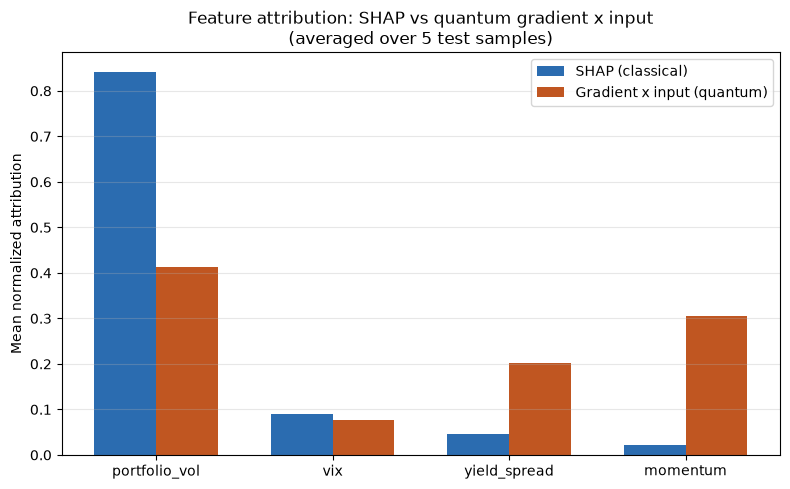

Saved figure: figures/06_attribution_comparison.png


In [7]:
shap_mean = shap_norm.mean(axis=0)
quantum_mean = quantum_norm.mean(axis=0)

x_pos = np.arange(len(selected_features))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_pos - width/2, shap_mean, width, label='SHAP (classical)', color='#2b6cb0')
ax.bar(x_pos + width/2, quantum_mean, width, label='Gradient x input (quantum)', color='#c05621')
ax.set_xticks(x_pos)
ax.set_xticklabels(selected_features)
ax.set_ylabel('Mean normalized attribution')
ax.set_title('Feature attribution: SHAP vs quantum gradient x input\n(averaged over 5 test samples)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.savefig('../figures/06_attribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/06_attribution_comparison.png")

## Rank correlation

In [8]:
from scipy.stats import spearmanr

shap_rank = pd.Series(shap_mean, index=selected_features).rank(ascending=False)
quantum_rank = pd.Series(quantum_mean, index=selected_features).rank(ascending=False)

print("Feature ranking (1 = most important):")
print(pd.DataFrame({'SHAP rank': shap_rank, 'Quantum rank': quantum_rank}))

corr, pvalue = spearmanr(shap_mean, quantum_mean)
print(f"\nSpearman rank correlation: {corr:.3f} (p={pvalue:.3f})")

Feature ranking (1 = most important):
               SHAP rank  Quantum rank
portfolio_vol        1.0           1.0
vix                  2.0           4.0
yield_spread         3.0           3.0
momentum             4.0           2.0

Spearman rank correlation: 0.200 (p=0.800)


## Check that every encoded feature reaches the readout

Repeat the input-gradient calculation with 20 independent weight sets. The check is not an
explanation result; it verifies that the revised paired readout does not make one wire
structurally invisible.

In [9]:
import pennylane as qml
from pennylane import numpy as pnp
from src.quantum_model import N_LAYERS

check_rng_seeds = range(20)
x_probe = pnp.array([0.5, 1.2, 0.8, 2.0], requires_grad=True)
grad_fn = qml.grad(circuit, argnums=0)

gradient_rows = []
for seed in check_rng_seeds:
    probe_rng = np.random.default_rng(seed)
    probe_weights = pnp.array(
        probe_rng.normal(0, 0.5, size=(N_LAYERS, N_QUBITS)),
        requires_grad=True,
    )
    gradient_rows.append(np.asarray(grad_fn(x_probe, probe_weights), dtype=float))

gradient_check = pd.DataFrame(np.abs(gradient_rows), columns=selected_features)
print("Maximum absolute input gradient across 20 random weight sets:")
print(gradient_check.max())
print()
print(f"Every feature visible: {(gradient_check.max() > 1e-8).all()}")

Maximum absolute input gradient across 20 random weight sets:
portfolio_vol    0.427330
vix              0.367751
yield_spread     0.234950
momentum         0.618530
dtype: float64

Every feature visible: True


**Interpretation**: both methods rank `portfolio_vol` first, but the remaining ordering differs.
SHAP ranks `vix`, `yield_spread`, then `momentum`; the VQC attribution ranks `momentum`,
`yield_spread`, then `vix`. Spearman correlation is 0.200 with p=0.800, so the five-day sample
does not support a claim of agreement. SHAP explains gradient boosting on the raw feature scale,
while gradient-times-input explains the angle-scaled VQC. The separate 20-weight check confirms
that all four encoded inputs can affect the paired readout.